## Import ไลบรารี และสร้างฟังก์ชันแปลงชื่อเดือน/ปี พ.ศ. เป็น ค.ศ.

In [1]:
import re
import pandas as pd
import numpy as np


# ฟังก์ชันแปลงชื่อคอลัมน์เดือนไทย (เช่น 'ม.ค. 2557' หรือ 'ม.ค.69') ให้เป็นรูปแบบ Date ('2014-01-01')
def convert_thai_month_to_date(col_name):
  if pd.isna(col_name):
    return col_name
  col_name = str(col_name).strip()

  # ถ้าเป็น YYYY-MM-DD อยู่แล้ว ให้ คืนค่าเดิม
  if re.match(r'^\d{4}-\d{2}-\d{2}', col_name):
    return col_name[:10]

  month_map = {
      'ม.ค.': '01',
      'ก.พ.': '02',
      'มี.ค.': '03',
      'เม.ย.': '04',
      'พ.ค.': '05',
      'มิ.ย.': '06',
      'ก.ค.': '07',
      'ส.ค.': '08',
      'ก.ย.': '09',
      'ต.ค.': '10',
      'พ.ย.': '11',
      'ธ.ค.': '12',
  }

  pattern = r'(ม\.ค\.|ก\.พ\.|มี\.ค\.|เม\.ย\.|พ\.ค\.|มิ\.ย\.|ก\.ค\.|ส\.ค\.|ก\.ย\.|ต\.ค\.|พ\.ย\.|ธ\.ค\.)\s*(\d{2,4})'
  match = re.search(pattern, col_name)

  if match:
    m_str, y_str = match.groups()
    month_str = month_map.get(m_str, '01')
    year_num = int(y_str)

    # แปลง พ.ศ. เป็น ค.ศ. (รองรับทั้งปี 2 หลัก เช่น 69 และ 4 หลัก เช่น 2569)
    if year_num < 100:
      year_ad = 2500 + year_num - 543
    elif year_num >= 2500:
      year_ad = year_num - 543
    else:
      year_ad = year_num

    return f'{year_ad}-{month_str}-01'

  return col_name


print('Cell 1: เตรียมฟังก์ชันเสร็จสิ้น')

Cell 1: เตรียมฟังก์ชันเสร็จสิ้น


## โหลดข้อมูลจากไฟล์ Excel ทั้ง 4 ตาราง

In [2]:
# ระบุ Path หรือชื่อไฟล์ Excel
file_tab4 = 'data/ตารางที่ 4 จำนวนผู้สมัครงานจำแนกตามประเภทอาชีพ(รายเดือน).xls'
file_tab5 = 'data/ตารางที่ 5 จำนวนผู้สมัครงานจำแนกตามอายุ(รายเดือน) .xls'
file_tab9 = 'data/ตารางที่ 9 จำนวนผู้บรรจุงานจำแนกตามประเภทอาชีพ(รายเดือน).xlsx'
file_tab14 = 'data/ตารางที่ 14 จำนวนตำแหน่งงานจำแนกตามระดับการศึกษา(รายเดือน).xls'

# อ่านไฟล์ Excel
df4 = pd.read_excel(file_tab4)
df5 = pd.read_excel(file_tab5)
df9 = pd.read_excel(file_tab9)
df14 = pd.read_excel(file_tab14)

print('df4 (ผู้สมัคร-อาชีพ) shape:', df4.shape)
print('df5 (ผู้สมัคร-อายุ) shape:', df5.shape)
print('df9 (บรรจุงาน-อาชีพ) shape:', df9.shape)
print('df14 (ตำแหน่งงาน-การศึกษา) shape:', df14.shape)

df4 (ผู้สมัคร-อาชีพ) shape: (12, 154)
df5 (ผู้สมัคร-อายุ) shape: (7, 153)
df9 (บรรจุงาน-อาชีพ) shape: (12, 154)
df14 (ตำแหน่งงาน-การศึกษา) shape: (8, 153)


## Clean และ Unpivot (Melt) ตาราง 4 และ 9 (มิติประเภทอาชีพ)

In [3]:
def process_occupation_table(df, value_name):
  # ทำความสะอาดชื่อคอลัมน์
  df.columns = df.columns.astype(str).str.strip()

  # ลบแถวที่เป็น 'รวม' ออกก่อน
  if 'รหัส' in df.columns:
    df = df[~df['รหัส'].astype(str).str.contains('รวม')].copy()

  # ใช้เฉพาะคอลัมน์ 'รหัส' เป็น ID (ตัด 'ประเภทอาชีพ' ออก)
  id_vars = ['รหัส']
  date_cols = [
      col for col in df.columns if col not in ['รหัส', 'ประเภทอาชีพ']
  ]

  # แปลงจาก Wide Format เป็น Long Format (Melt)
  df_melted = df.melt(
      id_vars=id_vars,
      value_vars=date_cols,
      var_name='month_year_raw',
      value_name=value_name,
  )

  # ทำความสะอาดรหัสอาชีพ (ตัดช่องว่าง)
  df_melted['รหัส'] = df_melted['รหัส'].astype(str).str.strip()

  # แปลงเดือน/ปี
  df_melted['date'] = df_melted['month_year_raw'].apply(
      convert_thai_month_to_date
  )

  # ทำความสะอาดตัวเลข (ลบเครื่องหมายจุลภาค , และแปลงเป็น numeric)
  df_melted[value_name] = (
      pd.to_numeric(
          df_melted[value_name].astype(str).str.replace(',', '').str.strip(),
          errors='coerce',
      )
      .fillna(0)
  )

  # ส่งคืนเฉพาะคอลัมน์ 'รหัส', 'date', และ ค่าตัวเลข
  return (
      df_melted[['รหัส', 'date', value_name]]
      .drop_duplicates(subset=['รหัส', 'date'])
      .reset_index(drop=True)
  )


# แปลงตาราง 4 และ 9 โดยใช้เฉพาะ รหัส
df4_long = process_occupation_table(df4, 'applicants_count')
df9_long = process_occupation_table(df9, 'placed_count')

print('ตัวอย่าง df4_long (ใช้เฉพาะรหัสตัวเลข):')

ตัวอย่าง df4_long (ใช้เฉพาะรหัสตัวเลข):


## รวมตาราง 4 และ 9 เข้าด้วยกัน (จอยระดับอาชีพ)

In [4]:
# Join ตาราง 4 (ผู้สมัคร) และ 9 (ผู้บรรจุ) ด้วย 'รหัส' และ 'date' เท่านั้น
df_occ_base = pd.merge(
    df4_long, df9_long, on=['รหัส', 'date'], how='outer'
).fillna(0)

print('shape หลังเชื่อมตาราง 4 และ 9:', df_occ_base.shape)
print(df_occ_base.head())

shape หลังเชื่อมตาราง 4 และ 9: (1824, 4)
  รหัส        date  applicants_count  placed_count
0    0  2014-01-01               0.0           0.0
1    0  2014-02-01               0.0           0.0
2    0  2014-03-01               0.0           0.0
3    0  2014-04-01               0.0           0.0
4    0  2014-05-01               0.0           0.0


## จัดการตาราง 5 (ผู้สมัครตามอายุ) ให้เป็น Macro Features รายเดือน

In [5]:
# ทำความสะอาดตาราง 5
df5.columns = df5.columns.astype(str).str.strip()

# ลบแถว 'รวม'
age_col = df5.columns[0]  # คอลัมน์แรกคือ 'อายุ'
df5 = df5[~df5[age_col].astype(str).str.contains('รวม')].copy()

date_cols_5 = [col for col in df5.columns if col != age_col]

df5_melted = df5.melt(
    id_vars=[age_col],
    value_vars=date_cols_5,
    var_name='month_year_raw',
    value_name='count',
)
df5_melted['date'] = df5_melted['month_year_raw'].apply(
    convert_thai_month_to_date
)
df5_melted['count'] = (
    pd.to_numeric(
        df5_melted['count'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce',
    )
    .fillna(0)
)

# Pivot ให้กลุ่มอายุกลายเป็น คอลัมน์ ใหม่ในแต่ละเดือน
df5_pivot = df5_melted.pivot_table(
    index='date', columns=age_col, values='count', aggfunc='sum'
).reset_index()

# เปลี่ยนชื่อคอลัมน์ให้สื่อความหมาย และลบช่องว่างส่วนเกิน
df5_pivot.columns = [
    'date' if c == 'date' else f'macro_applicants_age_{str(c).strip()}'
    for c in df5_pivot.columns
]

print('ตัวอย่าง Features จากตาราง 5:')
print(df5_pivot.head())

ตัวอย่าง Features จากตาราง 5:
         date  macro_applicants_age_15 - 17  macro_applicants_age_18 - 24  \
0  2014-01-01                            90                          8028   
1  2014-02-01                           373                         13312   
2  2014-03-01                           613                         16737   
3  2014-04-01                          1034                         16092   
4  2014-05-01                           295                         13378   

   macro_applicants_age_25 - 29  macro_applicants_age_30 - 39  \
0                          7420                         10483   
1                          9098                         12363   
2                          9041                         12168   
3                          9513                         12469   
4                          9686                         12735   

   macro_applicants_age_40 - 49  macro_applicants_age_50 - 59  \
0                          6481                    

## จัดการตาราง 14 (ตำแหน่งงานตามการศึกษา) ให้เป็น Macro Features รายเดือน

In [6]:
# ทำความสะอาดตาราง 14
df14.columns = df14.columns.astype(str).str.strip()

# ลบแถว 'รวม'
edu_col = df14.columns[0]  # คอลัมน์แรกคือ 'ระดับการศึกษา'
df14 = df14[~df14[edu_col].astype(str).str.contains('รวม')].copy()

date_cols_14 = [col for col in df14.columns if col != edu_col]

df14_melted = df14.melt(
    id_vars=[edu_col],
    value_vars=date_cols_14,
    var_name='month_year_raw',
    value_name='count',
)
df14_melted['date'] = df14_melted['month_year_raw'].apply(
    convert_thai_month_to_date
)
df14_melted['count'] = (
    pd.to_numeric(
        df14_melted['count'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce',
    )
    .fillna(0)
)

# Pivot ให้ระดับการศึกษากลายเป็น คอลัมน์ ใหม่ในแต่ละเดือน
df14_pivot = df14_melted.pivot_table(
    index='date', columns=edu_col, values='count', aggfunc='sum'
).reset_index()

# เปลี่ยนชื่อคอลัมน์ และลบช่องว่างส่วนเกิน
df14_pivot.columns = [
    'date' if c == 'date' else f'macro_vacancies_edu_{str(c).strip()}'
    for c in df14_pivot.columns
]

print('ตัวอย่าง Features จากตาราง 14:')
print(df14_pivot.head())

ตัวอย่าง Features จากตาราง 14:
         date  macro_vacancies_edu_1.  ประถมศึกษาและต่ำกว่า  \
0  2014-01-01                                        4958.0   
1  2014-02-01                                        4753.0   
2  2014-03-01                                        5698.0   
3  2014-04-01                                        5485.0   
4  2014-05-01                                        4477.0   

   macro_vacancies_edu_2.  มัธยมศึกษา  macro_vacancies_edu_3.  ปวช.  \
0                              8778.0                        4309.0   
1                              9041.0                        6924.0   
2                             11291.0                        5354.0   
3                             10913.0                        5338.0   
4                              8035.0                        4152.0   

   macro_vacancies_edu_4.  ปวส.  macro_vacancies_edu_5.  อนุปริญญา  \
0                        4565.0                             2291.0   
1                      

## รวมทุกตารางเข้าด้วยกันเป็น Master Dataset

In [7]:
# 1. นำข้อมูลหลัก (df_occ_base) จอยกับ Macro Features ตาราง 5 (อายุ) ด้วย 'date'
master_df = pd.merge(df_occ_base, df5_pivot, on='date', how='left')

# 2. จอยต่อกับ Macro Features ตาราง 14 (การศึกษา) ด้วย 'date'
master_df = pd.merge(master_df, df14_pivot, on='date', how='left')

# 3. จัดเรียงข้อมูลตามประเภท datetime
master_df['date'] = pd.to_datetime(master_df['date'])
master_df = master_df.sort_values(by=['รหัส', 'date']).reset_index(drop=True)

# เติมค่าว่างด้วย 0 (ถ้ามี)
master_df = master_df.fillna(0)
master_df = master_df[(master_df['รหัส'] != 'X') & (master_df['รหัส'] != 'T')]

print('รวมข้อมูลสำเร็จ! ขนาด Master Dataset:', master_df.shape)

รวมข้อมูลสำเร็จ! ขนาด Master Dataset: (1520, 19)


In [8]:
import numpy as np

# ป้องกันการหารด้วยศูนย์ (Division by Zero) ในกรณีที่ไม่มีผู้สมัคร
master_df['placement_rate'] = np.where(
    master_df['applicants_count'] > 0,
    master_df['placed_count'] / master_df['applicants_count'],
    0
)

# PCA

# Forecasting Model - ทำนายจำนวนผู้สมัครและการบรรจุงาน

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Tahoma'

# เลือก occupation code ที่มีข้อมูลสำคัญ (ข้อมูลที่มีค่า > 0)
active_codes = ['1', '2', '3', '4', '5', '7', '8', '9']

print('เตรียม Forecasting Model...')

เตรียม Forecasting Model...


In [10]:
# ประกอบข้อมูลทั้งหมด (รวมทุก occupation code) สำหรับ forecasting
forecast_df = master_df[master_df['รหัส'].isin(active_codes)].copy()

# รวมข้อมูล applicants_count และ placed_count รายเดือน (ทั้งหมด)
ts_data = forecast_df.groupby('date').agg({
    'applicants_count': 'sum',
    'placed_count': 'sum',
    'placement_rate': 'mean'
}).reset_index()

ts_data['date'] = pd.to_datetime(ts_data['date'])
ts_data = ts_data.sort_values('date').reset_index(drop=True)

print('Time Series Data Shape:', ts_data.shape)
print('Date Range:', ts_data['date'].min(), 'to', ts_data['date'].max())
print('\nข้อมูลล่าสุด 12 เดือน:')
print(ts_data.tail(12))

Time Series Data Shape: (152, 4)
Date Range: 2014-01-01 00:00:00 to 2026-08-01 00:00:00

ข้อมูลล่าสุด 12 เดือน:
          date  applicants_count  placed_count  placement_rate
140 2025-09-01           14209.0        8960.0        0.567149
141 2025-10-01           20157.0       13528.0        0.584939
142 2025-11-01           25081.0       16602.0        0.586544
143 2025-12-01           26452.0       18231.0        0.593599
144 2026-01-01           26254.0       15043.0        0.492463
145 2026-02-01           26930.0       17903.0        0.568509
146 2026-03-01           25188.0       17344.0        0.588279
147 2026-04-01           23512.0       16046.0        0.584853
148 2026-05-01           23245.0       16201.0        0.603696
149 2026-06-01           21848.0       15295.0        0.619266
150 2026-07-01           19137.0       12875.0        0.589765
151 2026-08-01           16151.0       10064.0        0.544295


In [11]:
# === ARIMA Forecasting ===
print('\n' + '='*70)
print('ARIMA Model (Auto Regressive Integrated Moving Average)')
print('='*70 + '\n')

forecast_steps = 12
last_date = ts_data['date'].max()
forecast_dates = pd.date_range(start=last_date + timedelta(days=1), periods=forecast_steps, freq='MS')

# ฝึกโมเดล ARIMA สำหรับ applicants_count
arima_applicants = ARIMA(ts_data['applicants_count'], order=(1,1,1))
arima_fit_app = arima_applicants.fit()

forecast_arima_app = arima_fit_app.get_forecast(steps=forecast_steps)
forecast_app_mean = forecast_arima_app.predicted_mean

# ฝึกโมเดล ARIMA สำหรับ placed_count
arima_placed = ARIMA(ts_data['placed_count'], order=(1,1,1))
arima_fit_pl = arima_placed.fit()

forecast_arima_pl = arima_fit_pl.get_forecast(steps=forecast_steps)
forecast_pl_mean = forecast_arima_pl.predicted_mean

# สร้าง DataFrame สำหรับผลการทำนาย ARIMA
forecast_result_arima = pd.DataFrame({
    'date': forecast_dates,
    'applicants_forecast': forecast_app_mean.values,
    'placed_forecast': forecast_pl_mean.values,
    'model': 'ARIMA'
})

print('ARIMA Forecast Results (ถัดไป 12 เดือน):')
print(forecast_result_arima.to_string())


ARIMA Model (Auto Regressive Integrated Moving Average)

ARIMA Forecast Results (ถัดไป 12 เดือน):
         date  applicants_forecast  placed_forecast  model
0  2026-09-01         16923.737972     11916.790552  ARIMA
1  2026-10-01         17613.900356     13035.727235  ARIMA
2  2026-11-01         18230.311264     13711.475122  ARIMA
3  2026-12-01         18780.851857     14119.572572  ARIMA
4  2027-01-01         19272.561107     14366.030655  ARIMA
5  2027-02-01         19711.725791     14514.871543  ARIMA
6  2027-03-01         20103.960877     14604.759484  ARIMA
7  2027-04-01         20454.281311     14659.044581  ARIMA
8  2027-05-01         20767.166136     14691.828420  ARIMA
9  2027-06-01         21046.615762     14711.627226  ARIMA
10 2027-07-01         21296.203108     14723.584114  ARIMA
11 2027-08-01         21519.119289     14730.805114  ARIMA


In [12]:
# === Exponential Smoothing Forecasting ===
print('\n' + '='*70)
print('Exponential Smoothing Model (with Seasonal Pattern)')
print('='*70 + '\n')

try:
    exp_smooth_app = ExponentialSmoothing(
        ts_data['applicants_count'],
        seasonal_periods=12,
        trend='add',
        seasonal='add',
        initialization_method='estimated'
    )
    exp_fit_app = exp_smooth_app.fit(optimized=True)
    forecast_exp_app = exp_fit_app.get_forecast(steps=forecast_steps).predicted_mean

    # ทำนาย placed_count ด้วย Exponential Smoothing
    exp_smooth_pl = ExponentialSmoothing(
        ts_data['placed_count'],
        seasonal_periods=12,
        trend='add',
        seasonal='add',
        initialization_method='estimated'
    )
    exp_fit_pl = exp_smooth_pl.fit(optimized=True)
    forecast_exp_pl = exp_fit_pl.get_forecast(steps=forecast_steps).predicted_mean

    # สร้าง DataFrame
    forecast_result_exp = pd.DataFrame({
        'date': forecast_dates,
        'applicants_forecast': forecast_exp_app.values,
        'placed_forecast': forecast_exp_pl.values,
        'model': 'Exp Smoothing'
    })

    print('Exponential Smoothing Forecast Results:')
    print(forecast_result_exp.to_string())
except Exception as e:
    print(f'Error in Exponential Smoothing: {e}')
    forecast_result_exp = None


Exponential Smoothing Model (with Seasonal Pattern)

Error in Exponential Smoothing: 'HoltWintersResults' object has no attribute 'get_forecast'


In [13]:
# === Linear Regression with Trend ===
print('\n' + '='*70)
print('Linear Regression Model (Linear Trend)')
print('='*70 + '\n')

# แปลงวันที่เป็นตัวเลข (วันนับจากวันแรก)
ts_data['date_numeric'] = (ts_data['date'] - ts_data['date'].min()).dt.days

X = ts_data['date_numeric'].values.reshape(-1, 1)
y_app = ts_data['applicants_count'].values
y_pl = ts_data['placed_count'].values

# ฝึก Linear Regression
lr_app = LinearRegression()
lr_app.fit(X, y_app)

lr_pl = LinearRegression()
lr_pl.fit(X, y_pl)

# ทำนายสำหรับ 12 เดือนถัดไป
future_days = [(ts_data['date'].max() - ts_data['date'].min()).days + (i+1)*30 for i in range(forecast_steps)]
X_future = np.array(future_days).reshape(-1, 1)

forecast_lr_app = lr_app.predict(X_future)
forecast_lr_pl = lr_pl.predict(X_future)

# สร้าง DataFrame
forecast_result_lr = pd.DataFrame({
    'date': forecast_dates,
    'applicants_forecast': forecast_lr_app,
    'placed_forecast': forecast_lr_pl,
    'model': 'Linear Trend'
})

print('Linear Regression Forecast Results:')
print(forecast_result_lr.to_string())
print('\nModel Performance:')
print(f'R² Score (applicants): {lr_app.score(X, y_app):.4f}')
print(f'R² Score (placed): {lr_pl.score(X, y_pl):.4f}')


Linear Regression Model (Linear Trend)

Linear Regression Forecast Results:
         date  applicants_forecast  placed_forecast         model
0  2026-09-01         20211.197890     12394.019416  Linear Trend
1  2026-10-01         20147.320058     12259.383489  Linear Trend
2  2026-11-01         20083.442227     12124.747563  Linear Trend
3  2026-12-01         20019.564395     11990.111636  Linear Trend
4  2027-01-01         19955.686564     11855.475709  Linear Trend
5  2027-02-01         19891.808732     11720.839782  Linear Trend
6  2027-03-01         19827.930901     11586.203855  Linear Trend
7  2027-04-01         19764.053069     11451.567928  Linear Trend
8  2027-05-01         19700.175238     11316.932001  Linear Trend
9  2027-06-01         19636.297406     11182.296074  Linear Trend
10 2027-07-01         19572.419574     11047.660148  Linear Trend
11 2027-08-01         19508.541743     10913.024221  Linear Trend

Model Performance:
R² Score (applicants): 0.0564
R² Score (place

In [14]:
# === Model Comparison & Ensemble Average ===
print('\n' + '='*70)
print('Model Comparison & Ensemble Average')
print('='*70 + '\n')

# รวม forecast จากทั้งหมด
if forecast_result_exp is not None:
    all_forecasts = pd.concat([
        forecast_result_arima,
        forecast_result_exp,
        forecast_result_lr
    ], ignore_index=True)
else:
    all_forecasts = pd.concat([
        forecast_result_arima,
        forecast_result_lr
    ], ignore_index=True)

# หา Average forecast (Ensemble)
avg_forecast = all_forecasts.groupby('date').agg({
    'applicants_forecast': 'mean',
    'placed_forecast': 'mean'
}).reset_index()
avg_forecast['model'] = 'Ensemble Average'

# รวม Forecast Results ทั้งหมด
final_forecast = pd.concat([all_forecasts, avg_forecast], ignore_index=True)

print('Ensemble Average Forecast Results:')
ensemble_data = final_forecast[final_forecast['model'] == 'Ensemble Average'].copy()
ensemble_data['date_str'] = ensemble_data['date'].dt.strftime('%B %Y')
for idx, row in ensemble_data.iterrows():
    print(f"{row['date_str']:20} | Applicants: {row['applicants_forecast']:>10,.0f} | Placed: {row['placed_forecast']:>10,.0f}")


Model Comparison & Ensemble Average

Ensemble Average Forecast Results:
September 2026       | Applicants:     18,567 | Placed:     12,155
October 2026         | Applicants:     18,881 | Placed:     12,648
November 2026        | Applicants:     19,157 | Placed:     12,918
December 2026        | Applicants:     19,400 | Placed:     13,055
January 2027         | Applicants:     19,614 | Placed:     13,111
February 2027        | Applicants:     19,802 | Placed:     13,118
March 2027           | Applicants:     19,966 | Placed:     13,095
April 2027           | Applicants:     20,109 | Placed:     13,055
May 2027             | Applicants:     20,234 | Placed:     13,004
June 2027            | Applicants:     20,341 | Placed:     12,947
July 2027            | Applicants:     20,434 | Placed:     12,886
August 2027          | Applicants:     20,514 | Placed:     12,822



Forecasting Visualization



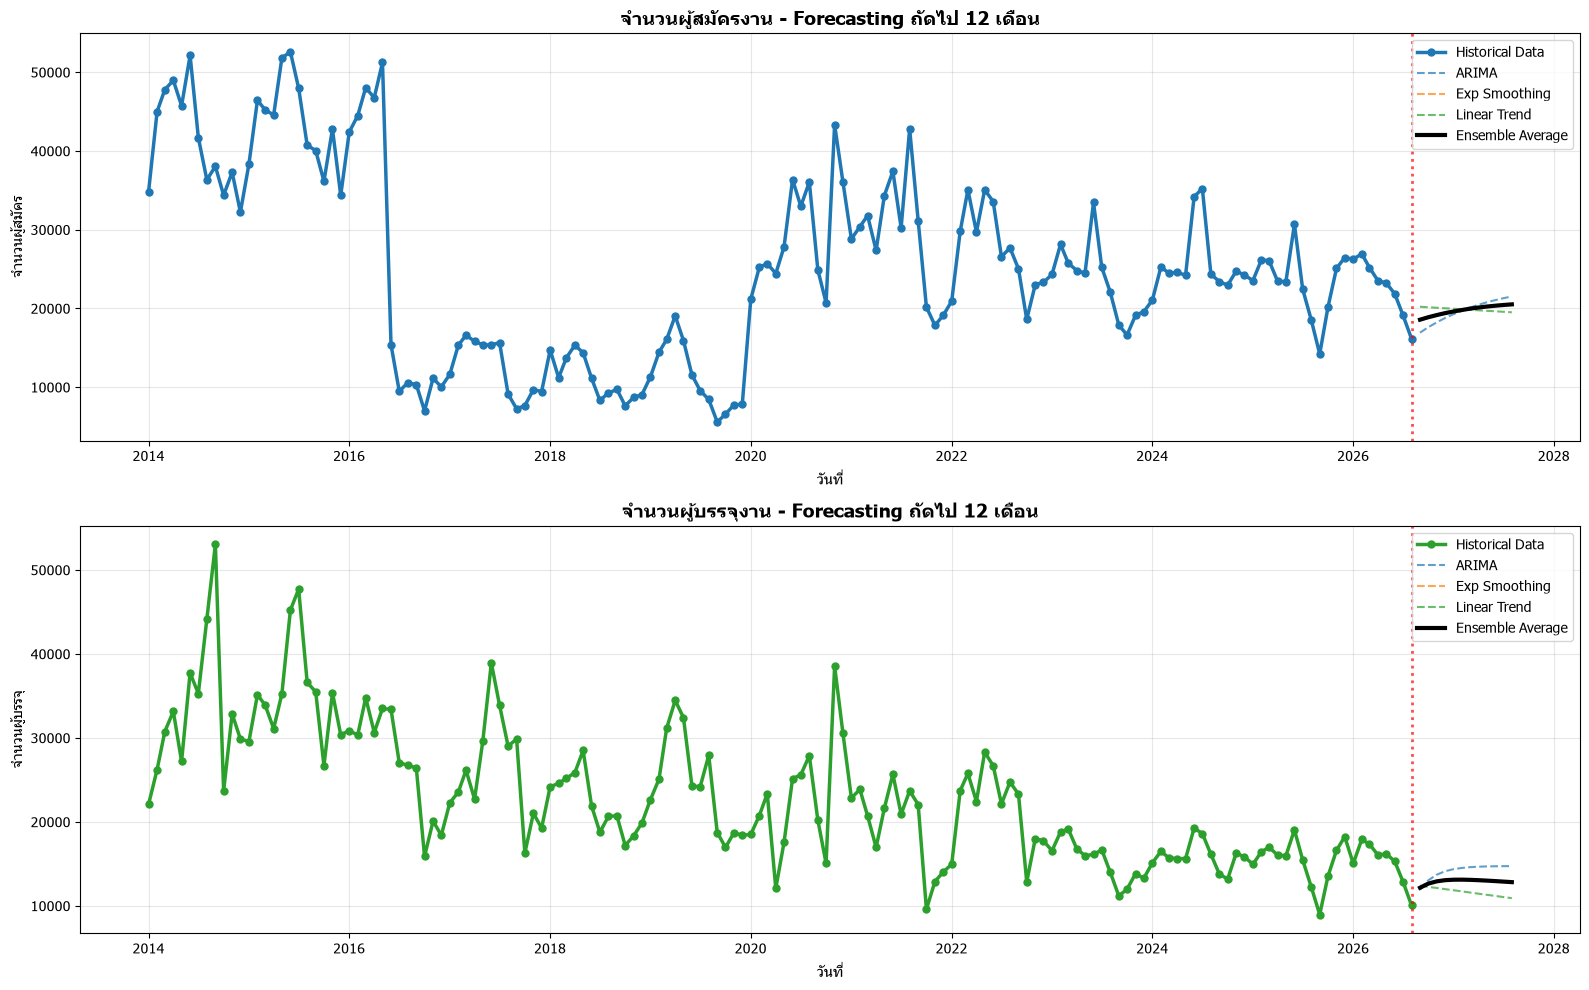

Visualization Complete!


In [15]:
# === Visualization ===
print('\n' + '='*70)
print('Forecasting Visualization')
print('='*70 + '\n')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Applicants Forecast
ax1 = axes[0]
ax1.plot(ts_data['date'], ts_data['applicants_count'], 'o-', label='Historical Data', 
         linewidth=2.5, markersize=5, color='#1f77b4')

# พล็อต Forecast จากแต่ละโมเดล
for model in ['ARIMA', 'Exp Smoothing', 'Linear Trend']:
    model_data = final_forecast[final_forecast['model'] == model]
    ax1.plot(model_data['date'], model_data['applicants_forecast'], '--', 
            label=f'{model}', linewidth=1.5, alpha=0.7)

# พล็อต Ensemble Average
ensemble_data_plot = final_forecast[final_forecast['model'] == 'Ensemble Average']
ax1.plot(ensemble_data_plot['date'], ensemble_data_plot['applicants_forecast'], '-', 
        label='Ensemble Average', linewidth=3, color='black')

ax1.axvline(x=ts_data['date'].max(), color='red', linestyle=':', alpha=0.7, linewidth=2)
ax1.set_title('จำนวนผู้สมัครงาน - Forecasting ถัดไป 12 เดือน', fontsize=14, fontweight='bold')
ax1.set_xlabel('วันที่', fontsize=11)
ax1.set_ylabel('จำนวนผู้สมัคร', fontsize=11)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Placed Forecast
ax2 = axes[1]
ax2.plot(ts_data['date'], ts_data['placed_count'], 'o-', label='Historical Data', 
         linewidth=2.5, markersize=5, color='#2ca02c')

for model in ['ARIMA', 'Exp Smoothing', 'Linear Trend']:
    model_data = final_forecast[final_forecast['model'] == model]
    ax2.plot(model_data['date'], model_data['placed_forecast'], '--', 
            label=f'{model}', linewidth=1.5, alpha=0.7)

ensemble_data_plot = final_forecast[final_forecast['model'] == 'Ensemble Average']
ax2.plot(ensemble_data_plot['date'], ensemble_data_plot['placed_forecast'], '-', 
        label='Ensemble Average', linewidth=3, color='black')

ax2.axvline(x=ts_data['date'].max(), color='red', linestyle=':', alpha=0.7, linewidth=2)
ax2.set_title('จำนวนผู้บรรจุงาน - Forecasting ถัดไป 12 เดือน', fontsize=14, fontweight='bold')
ax2.set_xlabel('วันที่', fontsize=11)
ax2.set_ylabel('จำนวนผู้บรรจุ', fontsize=11)
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Visualization Complete!')

In [16]:
# === Summary Report ===
print('\n' + '='*80)
print('📊 FORECASTING SUMMARY REPORT - ทำนายจำนวนผู้สมัครและการบรรจุงาน')
print('='*80)

summary_ensemble = ensemble_data[['date', 'applicants_forecast', 'placed_forecast']].copy()
summary_ensemble['date_str'] = summary_ensemble['date'].dt.strftime('%B %Y')
summary_ensemble['placement_rate_forecast'] = (summary_ensemble['placed_forecast'] / summary_ensemble['applicants_forecast'] * 100).round(2)

print('\n📈 ENSEMBLE AVERAGE FORECAST (รวมทั้ง 3 โมเดล)')
print('-'*80)
print(f"{'Month':20} | {'Applicants':>12} | {'Placed':>12} | {'Placement Rate':>15}")
print('-'*80)
for idx, row in summary_ensemble.iterrows():
    print(f"{row['date_str']:20} | {row['applicants_forecast']:>12,.0f} | {row['placed_forecast']:>12,.0f} | {row['placement_rate_forecast']:>14.2f}%")

print('\n' + '='*80)
print('📌 Model Descriptions:')
print('-'*80)
print('1. ARIMA (Auto Regressive Integrated Moving Average)')
print('   - Time series model ที่ใช้ค่าอดีต (Autoregressive) และ Moving Average')
print('   - เหมาะสำหรับข้อมูลที่มีเทรนด์และความเป็นระยะการ')
print()
print('2. Exponential Smoothing (with Seasonal Pattern)')
print('   - ให้น้ำหนักมากกว่าให้กับข้อมูลล่าสุด')
print('   - พิจารณาปกติเป็นรายปี (12-month seasonality)')
print()
print('3. Linear Regression (Linear Trend)')
print('   - โมเดลเชิงเส้นง่าย ๆ')
print('   - ใช้สำหรับการทำนายด้วยเทรนด์เชิงเส้น')
print()
print('4. Ensemble Average (แนะนำให้ใช้)')
print('   - ค่าเฉลี่ยของทั้ง 3 โมเดล')
print('   - โดยทั่วไปให้ผลลัพธ์ที่เสถียรและเชื่อถือได้มากกว่า')
print('='*80)


📊 FORECASTING SUMMARY REPORT - ทำนายจำนวนผู้สมัครและการบรรจุงาน

📈 ENSEMBLE AVERAGE FORECAST (รวมทั้ง 3 โมเดล)
--------------------------------------------------------------------------------
Month                |   Applicants |       Placed |  Placement Rate
--------------------------------------------------------------------------------
September 2026       |       18,567 |       12,155 |          65.47%
October 2026         |       18,881 |       12,648 |          66.99%
November 2026        |       19,157 |       12,918 |          67.43%
December 2026        |       19,400 |       13,055 |          67.29%
January 2027         |       19,614 |       13,111 |          66.84%
February 2027        |       19,802 |       13,118 |          66.25%
March 2027           |       19,966 |       13,095 |          65.59%
April 2027           |       20,109 |       13,055 |          64.92%
May 2027             |       20,234 |       13,004 |          64.27%
June 2027            |       20,341 